"""
Count unique patient IDs across the records500 subfolders.

Assumes filenames of the form "<patient_id>_hr.dat" or "<patient_id>_hr.hea".
Extracts the substring before "_hr" as the patient ID.
"""

In [1]:

import os

main_dataset_folder = "./dataset"
records500_path = os.path.join(main_dataset_folder, "records500")

total_unique_patients = set()

if not os.path.isdir(records500_path):
    print(f"records500 path not found: {records500_path}")
else:
    for subfolder_name in sorted(os.listdir(records500_path)):
        subfolder_full_path = os.path.join(records500_path, subfolder_name)
        if not os.path.isdir(subfolder_full_path):
            print(f"  '{subfolder_name}' is not a directory.")
            continue

        for item in os.listdir(subfolder_full_path):
            if item.endswith((".dat", ".hea")) and "_hr" in item:
                patient_id = item.split("_hr")[0]
                total_unique_patients.add(patient_id)

print(f"\nTotal unique patient records across all subfolders: {len(total_unique_patients)}")


Total unique patient records across all subfolders: 21799


In [2]:
import pandas as pd

# Load scp_statements_df if not already loaded
if 'scp_statements_df' not in locals():
    scp_path = os.path.join(main_dataset_folder, 'scp_statements.csv')
    scp_statements_df = pd.read_csv(scp_path, index_col=0)

# Define superclasses
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# Create mapping if not already exists
if 'scp_to_superclass_map' not in locals():
    scp_to_superclass_map = {}
    if 'diagnostic_class' in scp_statements_df.columns:
        for scp_code in scp_statements_df.index:
            class_val = scp_statements_df.loc[scp_code, 'diagnostic_class']
            scp_to_superclass_map[scp_code] = class_val if pd.notna(class_val) and class_val in SUPERCLASSES else 'OTH'

# Display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Prepare output dataframe
output_rows = []
for scp_code in scp_statements_df.index:
    description = scp_statements_df.loc[scp_code, 'description']
    subclass = scp_statements_df.loc[scp_code, 'diagnostic_subclass'] if pd.notna(scp_statements_df.loc[scp_code, 'diagnostic_subclass']) else 'N/A'
    
    output_rows.append({
        'SCP Code': scp_code,
        'Subclass': subclass,
        'Description': description,
        'Mapped Superclass': scp_to_superclass_map.get(scp_code, 'OTH')
    })

output_df = pd.DataFrame(output_rows)

# Reset display options
pd.reset_option('display.max_rows')
pd.reset_option('display.max_colwidth')
print(output_df.to_string())

   SCP Code   Subclass                                                   Description Mapped Superclass
0       NDT       STTC                                non-diagnostic T abnormalities              STTC
1      NST_       NST_                                       non-specific ST changes              STTC
2       DIG       STTC                                              digitalis-effect              STTC
3     LNGQT       STTC                                              long QT-interval              STTC
4      NORM       NORM                                                    normal ECG              NORM
5       IMI        IMI                                inferior myocardial infarction                MI
6      ASMI        AMI                            anteroseptal myocardial infarction                MI
7       LVH        LVH                                  left ventricular hypertrophy               HYP
8      LAFB  LAFB/LPFB                                left anterior fasci

Processing ECG signals and displaying diagnosis reports for Patient ID: 392 and ECG ID: 635 (from 00000 folder)


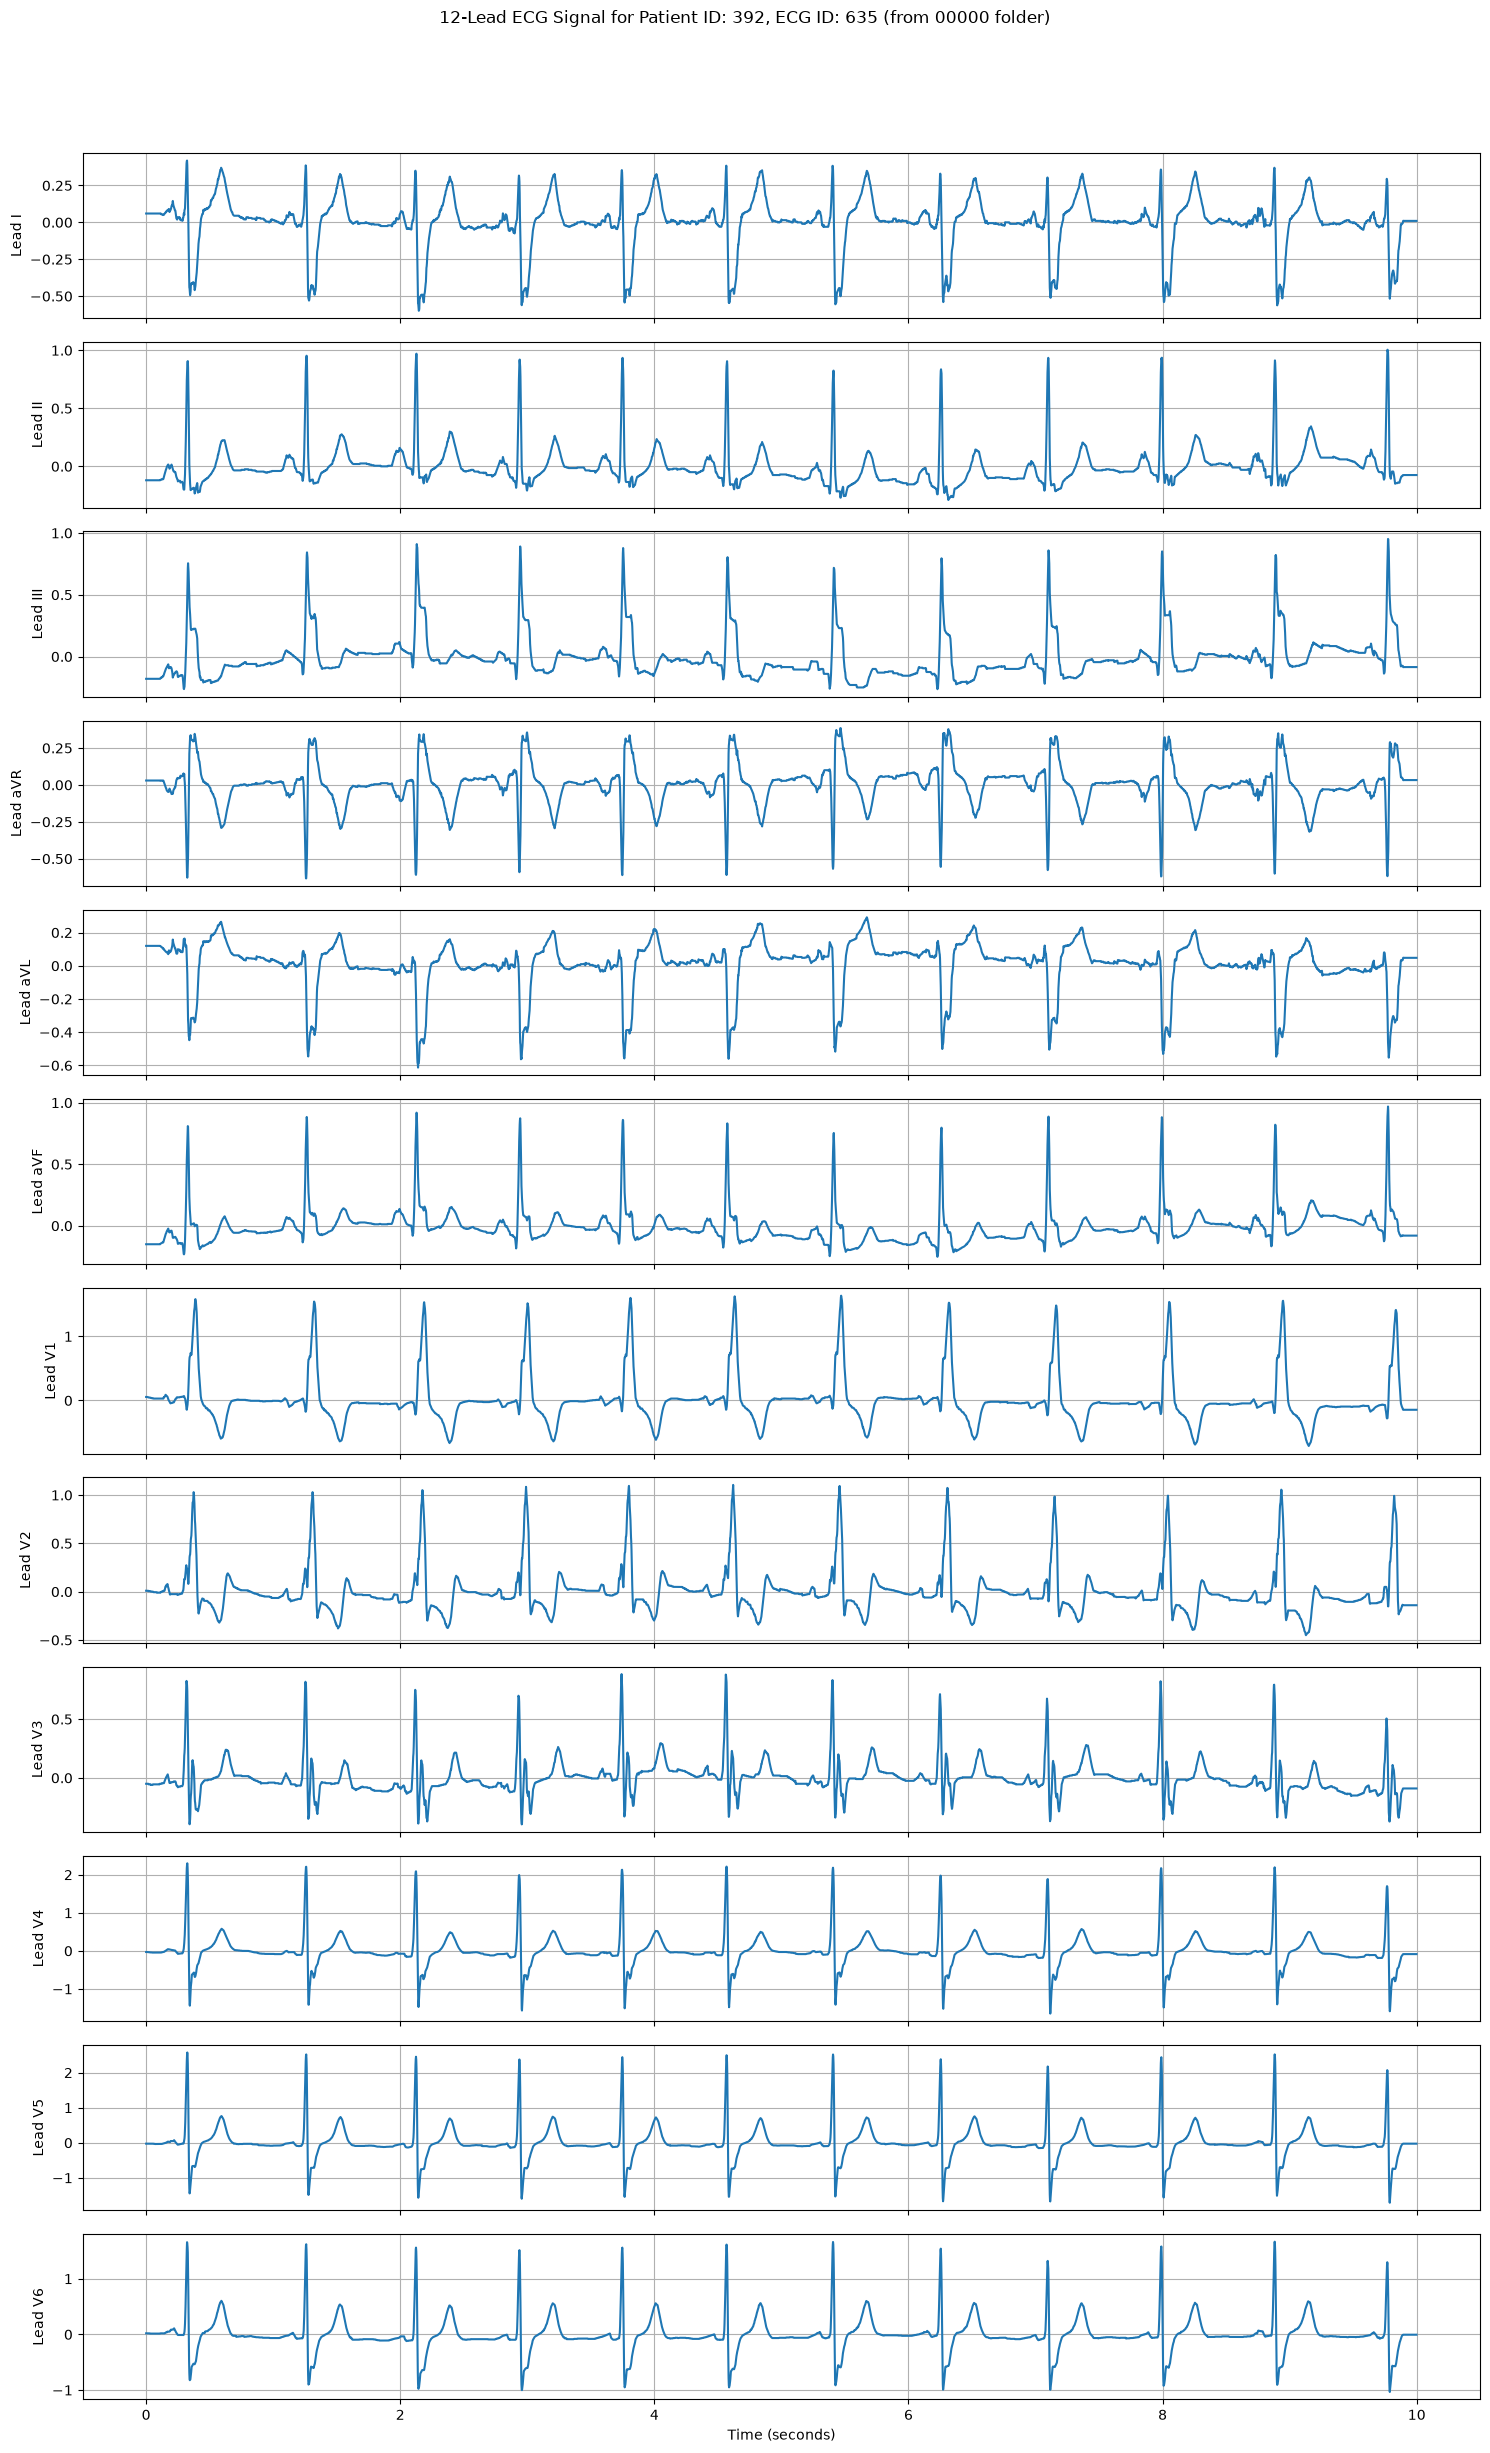

Diagnosis Report (SCP Codes): {'CLBBB': 100.0, 'LPFB': 100.0, 'RVH': 15.0, 'SR': 0.0}

Primary Diagnosis:
  - complete left bundle branch block (100.0%)
  - left posterior fascicular block (100.0%)
  - right ventricular hypertrophy (15.0%)
Heart Rhythm:
  - sinus rhythm (0.0%)
Wave Morphology: No findings
Other: No findings




In [3]:
import matplotlib.pyplot as plt
import numpy as np
import wfdb
import os
import pandas as pd
import json
import ast

if 'ptbxl_df' not in locals():
    ptbxl_df = pd.read_csv(os.path.join(main_dataset_folder, 'ptbxl_database.csv'), index_col='ecg_id')

patient_id_to_plot = 392
#371
patient_records_for_plot = ptbxl_df[(ptbxl_df['patient_id'] == patient_id_to_plot) &
                                     (ptbxl_df['filename_hr'].str.startswith('records500/00000/'))]

if patient_records_for_plot.empty:
    print(f"No records found for patient ID {int(patient_id_to_plot)} in the '00000' folder.")
else:
    # Extract the single record's details once
    ecg_id = patient_records_for_plot.index[0]
    record_row = patient_records_for_plot.iloc[0]
    filename_hr_path = record_row['filename_hr']
    scp_codes_diagnosis = record_row['scp_codes']

    print(f"Processing ECG signals and displaying diagnosis reports for Patient ID: {int(patient_id_to_plot)} and ECG ID: {ecg_id} (from 00000 folder)")
   
    # Extract subfolder and base_filename from filename_hr_path
    parts = filename_hr_path.split('/')
    records_folder_name = parts[0]
    subfolder_name = parts[1]
    base_filename = parts[2]

    # Construct the full path to the record
    record_path_base = os.path.join(main_dataset_folder, records_folder_name, subfolder_name, base_filename)

    try:
        # Load the raw record once and assign to record_raw for global use
        record_raw, header_data = wfdb.rdsamp(record_path_base)
        original_sr = header_data['fs'] # Get sampling frequency

        # Define variables used in downstream cells
        num_leads_denoising = record_raw.shape[1]
        # Create a time vector for plotting
        t = np.arange(0, len(record_raw)) / original_sr

        lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'] # Standard 12-lead ECG

        # Plotting for all leads of this specific record
        fig, axes = plt.subplots(num_leads_denoising, 1, figsize=(15, 2 * num_leads_denoising), sharex=True)

        for i in range(num_leads_denoising):
            axes[i].plot(t, record_raw[:, i]) # Use t for x-axis
            axes[i].set_ylabel(f'Lead {lead_names[i]}')
            axes[i].grid(True)

        plt.xlabel('Time (seconds)')
        plt.suptitle(f'12-Lead ECG Signal for Patient ID: {int(patient_id_to_plot)}, ECG ID: {ecg_id} (from 00000 folder)', y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        display(fig)
        plt.close(fig)

    except Exception as e:
        print(f"Error reading or plotting record {ecg_id}: {e}")


# Construct the path to scp_statements.csv
scp_path = os.path.join(main_dataset_folder, 'scp_statements.csv')

# Load scp_statements.csv
scp_statements_df = pd.read_csv(scp_path, index_col=0)

# Define the 5 superclasses for 'Primary Diagnosis'
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# Create a dictionary to store the mapping for easy lookup for primary diagnoses
scp_to_superclass_map = {}
if 'diagnostic_class' in scp_statements_df.columns:
    for scp_code in scp_statements_df.index:
        class_val = scp_statements_df.loc[scp_code, 'diagnostic_class']
        if pd.notna(class_val): # Ensure it's not NaN
            if class_val in SUPERCLASSES:
                scp_to_superclass_map[scp_code] = class_val
        # If class_val is NaN, it will be handled by other categories or 'Other'
else:
    pass # No direct superclass mapping if column not present

def get_scp_category(scp_code):
    """Categorizes an SCP code into 'Primary Diagnosis', 'Heart Rhythm', 'Wave Morphology', or 'Other'."""
 
    if scp_code not in scp_statements_df.index:
        return 'Other'

    # 1. Check for Primary Diagnosis based on mapped superclass
    if scp_code in scp_to_superclass_map and scp_to_superclass_map[scp_code] in SUPERCLASSES:
        return 'Primary Diagnosis'
    # 2. Check for Heart Rhythm
    elif pd.notna(scp_statements_df.loc[scp_code, 'rhythm']) and scp_statements_df.loc[scp_code, 'rhythm'] == 1.0:
        return 'Heart Rhythm'
    # 3. Check for Wave Morphology
    elif pd.notna(scp_statements_df.loc[scp_code, 'form']) and scp_statements_df.loc[scp_code, 'form'] == 1.0:
        return 'Wave Morphology'
    else:
        return 'Other'

if 'ecg_id' not in locals() or ecg_id is None:
    print(f"ECG ID not found. Please ensure the previous cell (plotting) ran successfully for patient ID {patient_id_to_plot}.")
else:
    print(f"Diagnosis Report (SCP Codes): {scp_codes_diagnosis}\n")

    scp_codes_str = scp_codes_diagnosis

    try:
        scp_codes_dict = json.loads(scp_codes_str.replace("'", '"'))
    except json.JSONDecodeError:
        try:
            scp_codes_dict = ast.literal_eval(scp_codes_str)
        except (ValueError, SyntaxError) as e:
            print(f"Error parsing scp_codes for ECG ID {ecg_id}: {e}")
            scp_codes_dict = {}

    categorized_diagnoses = {
        'Primary Diagnosis': [],
        'Heart Rhythm': [],
        'Wave Morphology': [],
        'Other': []
    }

    for scp_code, percentage in scp_codes_dict.items():
        category = get_scp_category(scp_code)
        description = scp_statements_df.loc[scp_code, 'description'] if scp_code in scp_statements_df.index else f"Unknown SCP Code ({scp_code})"
        categorized_diagnoses[category].append(f"{description} ({percentage:.1f}%)")

    for category, diagnoses_list in categorized_diagnoses.items():
        if diagnoses_list:
            print(f"{category}:")
            for diag in diagnoses_list:
                print(f"  - {diag}")
        else:
            print(f"{category}: No findings")
    print("\n")

In [1]:
import pandas as pd, os
df = pd.read_csv("./dataset/ptbxl_database.csv", index_col="ecg_id")
print("rows in CSV      :", len(df))
print("max ecg_id       :", df.index.max())
print("files on disk    :", sum(1 for r, d, fs in os.walk("./dataset/records500")
                                for f in fs if f.endswith("_hr.dat")))

rows in CSV      : 21799
max ecg_id       : 21837
files on disk    : 21799
